In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/amia-public-challenge-2026/sample_submission.csv
/kaggle/input/competitions/amia-public-challenge-2026/img_size.csv
/kaggle/input/competitions/amia-public-challenge-2026/train.csv
/kaggle/input/competitions/amia-public-challenge-2026/test.csv
/kaggle/input/competitions/amia-public-challenge-2026/test/test/MVPTnneogEY9HeghyRZ79B06zwbCXFb2.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/IPWtMk9UQm8WrDnexcxKPjb7pjbJH2fU.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/2ChzCiewt7Qv6V7PwpxHHNuEPzhV2zmt.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/g122exB2uiXm869vDsaKJVfutXVuRg0U.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/YHLcz1PmUvCnNyxGVwaj7QzfIUWW6UBE.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/e3l2DM0Ht466QyfnJKfXUL1CaoRTmXgN.png
/kaggle/input/competitions/amia-public-challenge-2026/test/test/tP5toJWlP9jvpB9ArxJzXIfLnU8hXuNl.png
/kaggle/input/competiti

In [2]:
!pip install segmentation-models-pytorch albumentations ensemble-boxes -q

import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import cv2
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

DATA_DIR      = '/kaggle/input/competitions/amia-public-challenge-2026'
TRAIN_IMG_DIR = '/kaggle/input/competitions/amia-public-challenge-2026/train/train'

train    = pd.read_csv(f'{DATA_DIR}/train.csv')
img_size = pd.read_csv(f'{DATA_DIR}/img_size.csv')

train = train.merge(img_size, on='image_id', how='left')
train['x_min'] = train['x_min'] / train['dim1'] * 1024
train['x_max'] = train['x_max'] / train['dim1'] * 1024
train['y_min'] = train['y_min'] / train['dim0'] * 1024
train['y_max'] = train['y_max'] / train['dim0'] * 1024

all_image_ids = train['image_id'].unique()
train_ids, val_ids = train_test_split(all_image_ids, test_size=0.2, random_state=42)
print("Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:0000:01
Done


In [4]:
from ensemble_boxes import weighted_boxes_fusion

def get_annotations_all(df, image_id):
    """Strategy 1: use all annotations as-is"""
    rows = df[(df['image_id'] == image_id) & (df['class_id'] != 14)]
    boxes = []
    for _, row in rows.iterrows():
        if pd.isna(row['x_min']):
            continue
        boxes.append({
            'class_id': int(row['class_id']),
            'x_min': row['x_min'],
            'y_min': row['y_min'],
            'x_max': row['x_max'],
            'y_max': row['y_max']
        })
    return boxes

def get_annotations_majority(df, image_id):
    """Strategy 2: only classes agreed by 2+ radiologists"""
    rows = df[(df['image_id'] == image_id) & (df['class_id'] != 14)]
    class_counts = rows['class_id'].value_counts()
    majority_classes = class_counts[class_counts >= 2].index.tolist()
    boxes = []
    for _, row in rows[rows['class_id'].isin(majority_classes)].iterrows():
        if pd.isna(row['x_min']):
            continue
        boxes.append({
            'class_id': int(row['class_id']),
            'x_min': row['x_min'],
            'y_min': row['y_min'],
            'x_max': row['x_max'],
            'y_max': row['y_max']
        })
    return boxes

def get_annotations_wbf(df, image_id):
    """Strategy 3: merge boxes using WBF"""
    rows = df[(df['image_id'] == image_id) & (df['class_id'] != 14)]
    if len(rows) == 0:
        return []
    
    boxes_list, scores_list, labels_list = [], [], []
    for rad_id in rows['rad_id'].unique():
        rad_rows = rows[rows['rad_id'] == rad_id]
        rad_boxes, rad_scores, rad_labels = [], [], []
        for _, row in rad_rows.iterrows():
            if pd.isna(row['x_min']):
                continue
            # normalize to 0~1 for WBF
            rad_boxes.append([
                row['x_min']/1024, row['y_min']/1024,
                row['x_max']/1024, row['y_max']/1024
            ])
            rad_scores.append(1.0)
            rad_labels.append(int(row['class_id']))
        if rad_boxes:
            boxes_list.append(rad_boxes)
            scores_list.append(rad_scores)
            labels_list.append(rad_labels)
    
    if not boxes_list:
        return []
    
    merged_boxes, merged_scores, merged_labels = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        iou_thr=0.5, skip_box_thr=0.0
    )
    
    result = []
    for box, label in zip(merged_boxes, merged_labels):
        result.append({
            'class_id': int(label),
            'x_min': box[0] * 1024,
            'y_min': box[1] * 1024,
            'x_max': box[2] * 1024,
            'y_max': box[3] * 1024
        })
    return result

print("Annotation strategies defined!")

Annotation strategies defined!


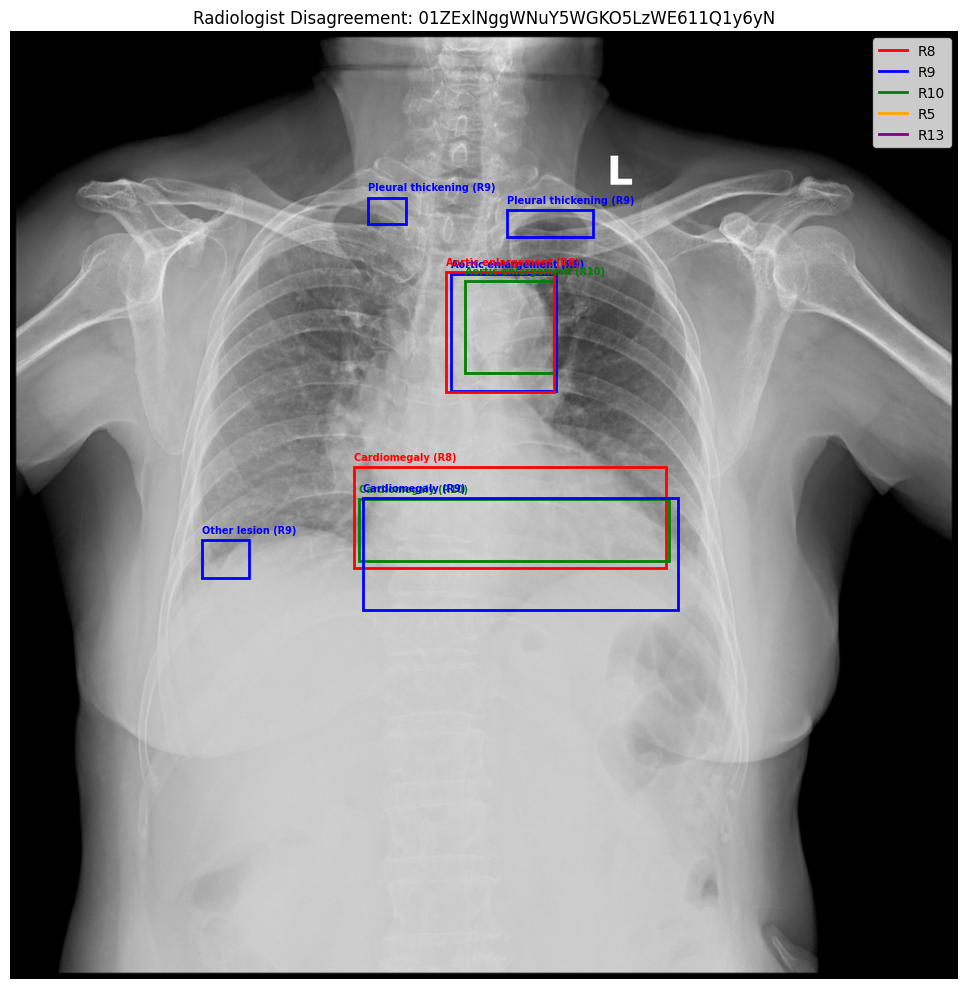

In [5]:
# EDA - some plots
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

CLASS_NAMES = ['Aortic enlargement','Atelectasis','Calcification','Cardiomegaly',
               'Consolidation','ILD','Infiltration','Lung Opacity','Nodule/Mass',
               'Other lesion','Pleural effusion','Pleural thickening',
               'Pneumothorax','Pulmonary fibrosis']

# radiologist color mapping
RAD_COLORS = {'R8': 'red', 'R9': 'blue', 'R10': 'green',
              'R5': 'orange', 'R13': 'purple'}

def visualize_radiologist_disagreement(image_id, df, img_dir):
    img_path = os.path.join(img_dir, f'{image_id}.png')
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (1024, 1024))

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image, cmap='gray')

    rows = df[(df['image_id'] == image_id) & (df['class_id'] != 14)]
    for _, row in rows.iterrows():
        if pd.isna(row['x_min']):
            continue
        color = RAD_COLORS.get(row['rad_id'], 'yellow')
        x, y = row['x_min'], row['y_min']
        w = row['x_max'] - row['x_min']
        h = row['y_max'] - row['y_min']
        rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                  edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-8, f"{CLASS_NAMES[int(row['class_id'])]} ({row['rad_id']})",
                color=color, fontsize=7, fontweight='bold')

    # legend
    for rad, color in RAD_COLORS.items():
        ax.plot([], [], color=color, label=rad, linewidth=2)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(f'Radiologist Disagreement: {image_id}', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_disagreement_{image_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

# find a good example image with multiple radiologists and findings
sample_ids = train[train['class_id'] != 14].groupby('image_id')['rad_id'].nunique()
sample_ids = sample_ids[sample_ids >= 2].index.tolist()
visualize_radiologist_disagreement(sample_ids[0], train, TRAIN_IMG_DIR)

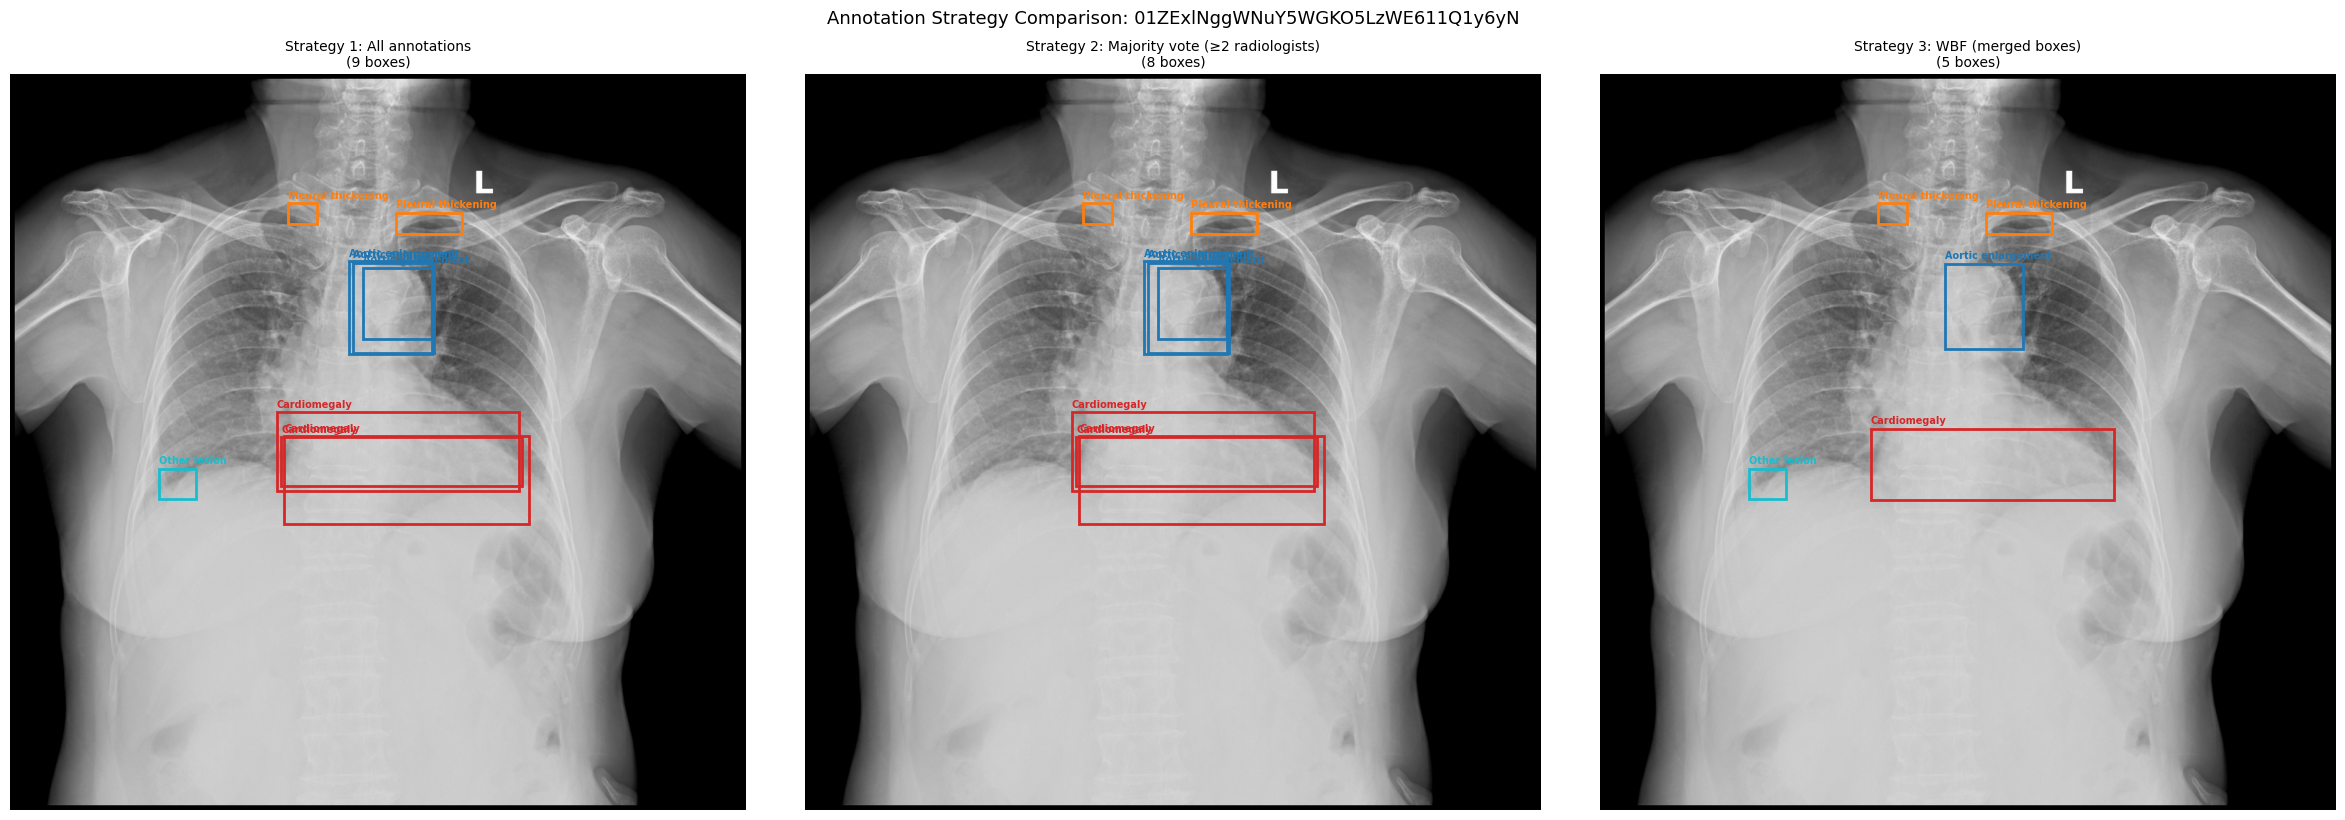

In [6]:
def visualize_annotation_strategies(image_id, df, img_dir):
    img_path = os.path.join(img_dir, f'{image_id}.png')
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (1024, 1024))

    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    titles = ['Strategy 1: All annotations', 
              'Strategy 2: Majority vote (≥2 radiologists)',
              'Strategy 3: WBF (merged boxes)']
    strategies = [get_annotations_all, get_annotations_majority, get_annotations_wbf]
    colors = plt.cm.tab10.colors

    for ax, title, strategy in zip(axes, titles, strategies):
        ax.imshow(image, cmap='gray')
        boxes = strategy(df, image_id)
        for box in boxes:
            x, y = box['x_min'], box['y_min']
            w = box['x_max'] - box['x_min']
            h = box['y_max'] - box['y_min']
            color = colors[box['class_id'] % len(colors)]
            rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                      edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y-8, CLASS_NAMES[box['class_id']],
                    color=color, fontsize=7, fontweight='bold')
        ax.set_title(f'{title}\n({len(boxes)} boxes)', fontsize=10)
        ax.axis('off')

    plt.suptitle(f'Annotation Strategy Comparison: {image_id}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_strategies_{image_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

# use same sample image
visualize_annotation_strategies(sample_ids[0], train, TRAIN_IMG_DIR)

In [9]:
IMG_SIZE = 512

class CXRDataset(Dataset):
    def __init__(self, image_ids, df, img_dir, transform=None, strategy='all'):
        self.image_ids = image_ids
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.strategy = strategy
        
        if strategy == 'all':
            self.get_boxes = get_annotations_all
        elif strategy == 'majority':
            self.get_boxes = get_annotations_majority
        elif strategy == 'wbf':
            self.get_boxes = get_annotations_wbf

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, f'{image_id}.png')
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = np.stack([image] * 3, axis=-1)

        mask = np.zeros((IMG_SIZE, IMG_SIZE, 14), dtype=np.float32)
        boxes = self.get_boxes(self.df, image_id)
        for box in boxes:
            x1 = int(box['x_min'] / 1024 * IMG_SIZE)
            y1 = int(box['y_min'] / 1024 * IMG_SIZE)
            x2 = int(box['x_max'] / 1024 * IMG_SIZE)
            y2 = int(box['y_max'] / 1024 * IMG_SIZE)
            mask[y1:y2, x1:x2, box['class_id']] = 1.0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.permute(2, 0, 1)
        return image, mask

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

print("Dataset class defined!")

Dataset class defined!


In [10]:
def train_and_evaluate(strategy_name, train_ids, val_ids, train_df, img_dir):
    print(f"\n{'='*50}")
    print(f"Strategy: {strategy_name}")
    print(f"{'='*50}")
    
    # datasets
    train_dataset = CXRDataset(train_ids, train_df, img_dir, 
                                transform=train_transform, strategy=strategy_name)
    val_dataset   = CXRDataset(val_ids, train_df, img_dir, 
                                transform=val_transform, strategy=strategy_name)
    train_loader  = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    val_loader    = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
    
    # model
    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=3,
        classes=14,
        activation=None
    ).cuda()
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    # train
    for epoch in range(10):
        model.train()
        train_loss = 0
        for images, masks in train_loader:
            images, masks = images.cuda(), masks.cuda()
            optimizer.zero_grad()
            loss = criterion(model(images), masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.cuda(), masks.cuda()
                val_loss += criterion(model(images), masks).item()
        
        print(f"Epoch {epoch+1}/10 | Train: {train_loss/len(train_loader):.4f} | Val: {val_loss/len(val_loader):.4f}")
    
    # evaluate dice/iou
    CLASS_NAMES = ['Aortic enlargement','Atelectasis','Calcification','Cardiomegaly',
                   'Consolidation','ILD','Infiltration','Lung Opacity','Nodule/Mass',
                   'Other lesion','Pleural effusion','Pleural thickening',
                   'Pneumothorax','Pulmonary fibrosis']
    
    model.eval()
    all_dice, all_iou, all_gt = [], [], []
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.cuda()
            masks_np = masks.numpy()
            outputs = torch.sigmoid(model(images)).cpu().numpy()
            for i in range(outputs.shape[0]):
                pred_bin = (outputs[i] > 0.5).astype(np.float32)
                eps = 1e-7
                intersection = (pred_bin * masks_np[i]).sum(axis=(1,2))
                union = pred_bin.sum(axis=(1,2)) + masks_np[i].sum(axis=(1,2))
                dice = (2*intersection+eps) / (union+eps)
                iou  = (intersection+eps) / (union-intersection+eps)
                all_dice.append(dice)
                all_iou.append(iou)
                all_gt.append(masks_np[i].sum(axis=(1,2)) > 0)
    
    all_dice = np.array(all_dice)
    all_iou  = np.array(all_iou)
    all_gt   = np.array(all_gt)
    
    # save model
    torch.save(model.state_dict(), f'/kaggle/working/unet_{strategy_name}.pth')
    
    # results
    results = []
    for c in range(14):
        mask_pos = all_gt[:, c]
        if mask_pos.sum() > 0:
            results.append({
                'class': CLASS_NAMES[c],
                'dice': all_dice[mask_pos, c].mean(),
                'iou': all_iou[mask_pos, c].mean(),
                'n_positive': mask_pos.sum()
            })
    
    df_result = pd.DataFrame(results)
    df_result.to_csv(f'/kaggle/working/results_{strategy_name}.csv', index=False)
    print(f"\nMean Dice: {df_result['dice'].mean():.4f}")
    print(f"Mean IoU:  {df_result['iou'].mean():.4f}")
    return df_result

# run all 3 strategies
results_all      = train_and_evaluate('all',      train_ids, val_ids, train, TRAIN_IMG_DIR)
results_majority = train_and_evaluate('majority', train_ids, val_ids, train, TRAIN_IMG_DIR)
results_wbf      = train_and_evaluate('wbf',      train_ids, val_ids, train, TRAIN_IMG_DIR)

print("\nAll strategies done!")


Strategy: all


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1/10 | Train: 0.2058 | Val: 0.0424
Epoch 2/10 | Train: 0.0302 | Val: 0.0225
Epoch 3/10 | Train: 0.0207 | Val: 0.0188
Epoch 4/10 | Train: 0.0175 | Val: 0.0165
Epoch 5/10 | Train: 0.0157 | Val: 0.0150
Epoch 6/10 | Train: 0.0146 | Val: 0.0144
Epoch 7/10 | Train: 0.0137 | Val: 0.0143
Epoch 8/10 | Train: 0.0130 | Val: 0.0132
Epoch 9/10 | Train: 0.0123 | Val: 0.0133
Epoch 10/10 | Train: 0.0117 | Val: 0.0133

Mean Dice: 0.1315
Mean IoU:  0.1101

Strategy: majority
Epoch 1/10 | Train: 0.1823 | Val: 0.0388
Epoch 2/10 | Train: 0.0279 | Val: 0.0195
Epoch 3/10 | Train: 0.0182 | Val: 0.0160
Epoch 4/10 | Train: 0.0151 | Val: 0.0138
Epoch 5/10 | Train: 0.0135 | Val: 0.0128
Epoch 6/10 | Train: 0.0127 | Val: 0.0128
Epoch 7/10 | Train: 0.0119 | Val: 0.0125
Epoch 8/10 | Train: 0.0111 | Val: 0.0117
Epoch 9/10 | Train: 0.0104 | Val: 0.0116
Epoch 10/10 | Train: 0.0100 | Val: 0.0112

Mean Dice: 0.0962
Mean IoU:  0.0788

Strategy: wbf
Epoch 1/10 | Train: 0.1657 | Val: 0.0398
Epoch 2/10 | Train: 0.0281 |

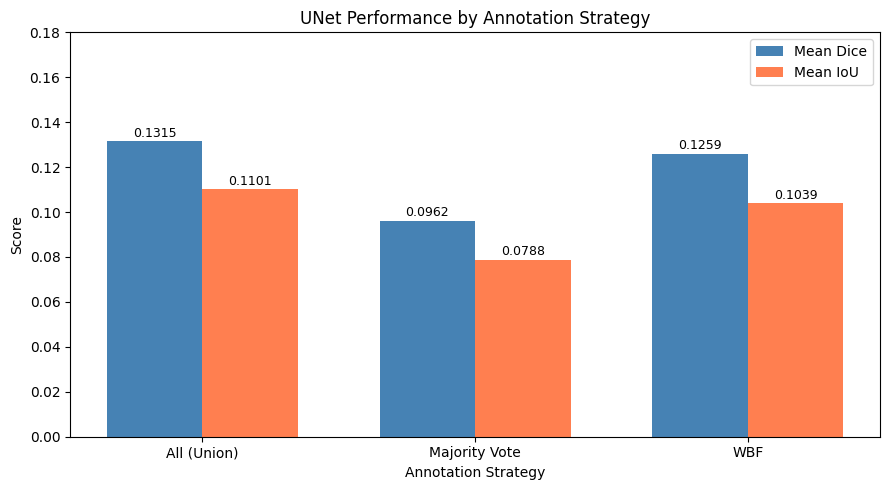

In [13]:
import matplotlib.pyplot as plt
import numpy as np

strategies = ['All (Union)', 'Majority Vote', 'WBF']
dice_scores = [0.1315, 0.0962, 0.1259]
iou_scores  = [0.1101, 0.0788, 0.1039]

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, dice_scores, width, label='Mean Dice', color='steelblue')
bars2 = ax.bar(x + width/2, iou_scores,  width, label='Mean IoU',  color='coral')

ax.set_xlabel('Annotation Strategy')
ax.set_ylabel('Score')
ax.set_title('UNet Performance by Annotation Strategy')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.set_ylim(0, 0.18)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/annotation_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()